# Suturing Quality Scoring - Paper Artifacts (Ticket 06)

One command turns the scored cohort CSVs (ticket 05) into the paper's
tables and figures: the official Val metrics, the AI-vs-expert agreement
table, and the correlation/calibration/trainee-level figures. This notebook
runs that command and shows the results.

In [1]:
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))

from IPython.display import Image, display
from suture_scoring.artifacts import generate_all

SCORES_DIR = ROOT / "outputs"
VAL_XLSX = ROOT / "Dataset/Val/Validation_cohort/Validation_annotations.xlsx"
ARTIFACTS = ROOT / "artifacts"

In [2]:
produced = generate_all(
    SCORES_DIR,
    VAL_XLSX,
    ARTIFACTS,
    expert_labels_xlsx=ROOT / "outputs/demo-expert-2week.xlsx",  # placeholder until real labels arrive
)
print("\n".join(f"- {p.name}" for p in produced.values()))


- val-metrics.md
- scatter-grid.png
- calibration-grid.png
- trainee-levels.png
- agreement.md
- manifest.md


In [3]:
print((ARTIFACTS / "val-metrics.md").read_text())

## Val metrics (official split, final numbers)

| output | mae | exact | +/-1 | spearman | ece |
|---|---|---|---|---|---|
| Overall | 1.054 | 0.320 | 0.568 | 0.421 | 0.101 |
| ISD | 1.238 | 0.194 | 0.636 | nan | 0.284 |
| Slack | 1.568 | 0.180 | 0.534 | nan | 0.242 |
| Position | 1.073 | 0.286 | 0.743 | nan | 0.190 |
| Angulation | 1.112 | 0.257 | 0.689 | nan | 0.230 |
| Width | 0.665 | 0.456 | 0.898 | nan | 0.088 |



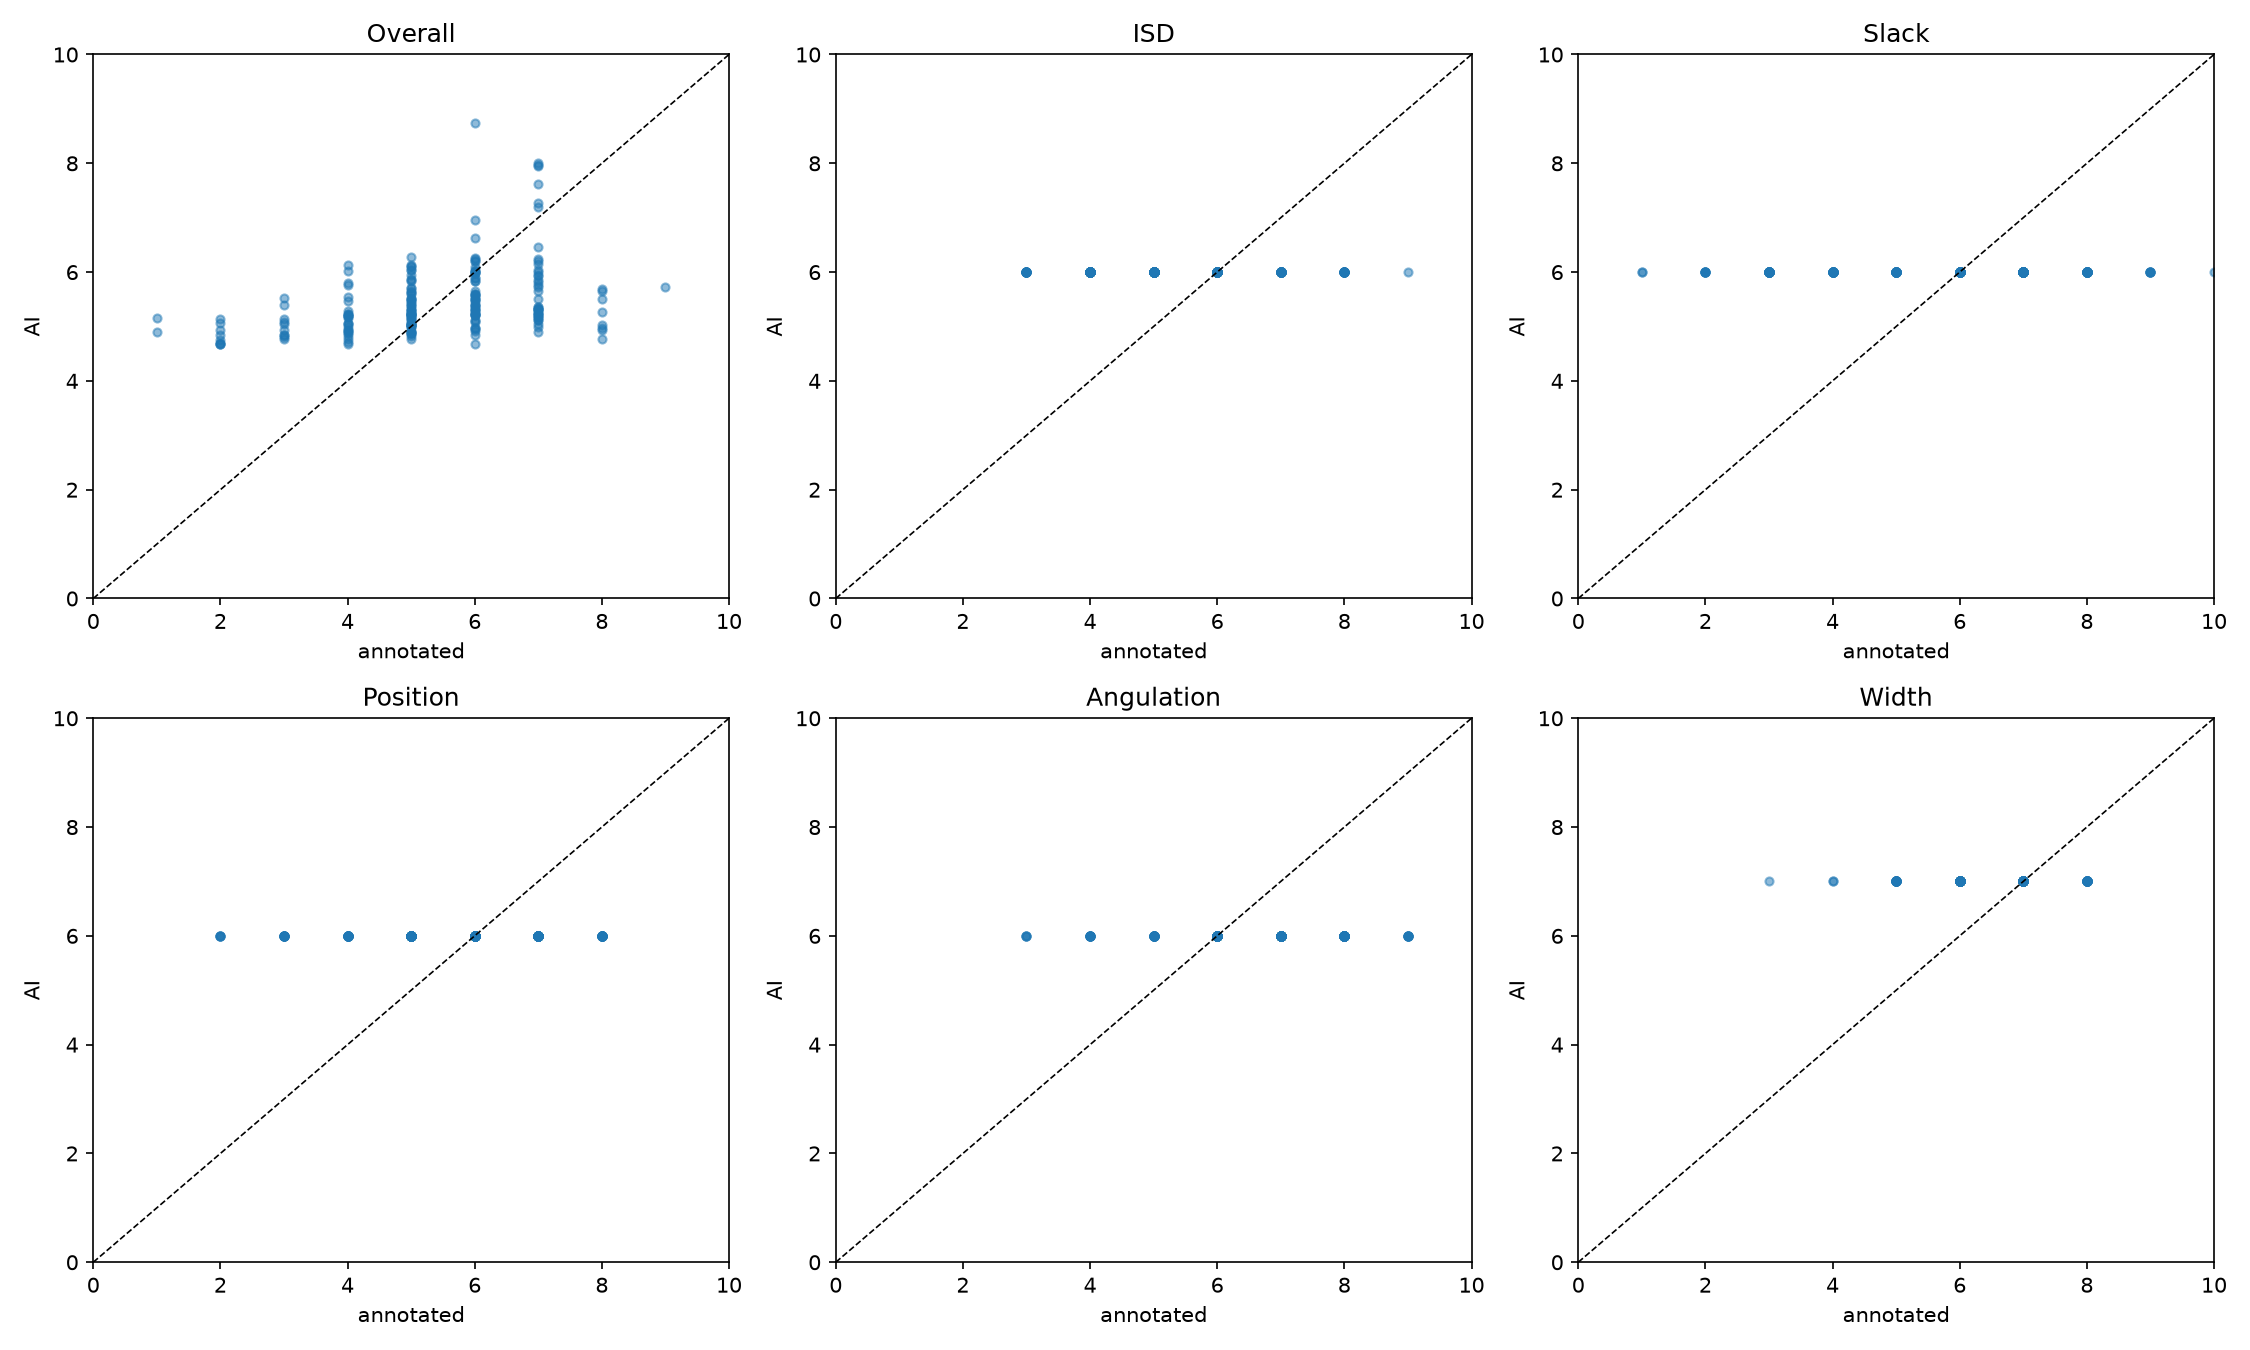

In [4]:
display(Image(filename=str(ARTIFACTS / "scatter-grid.png")))


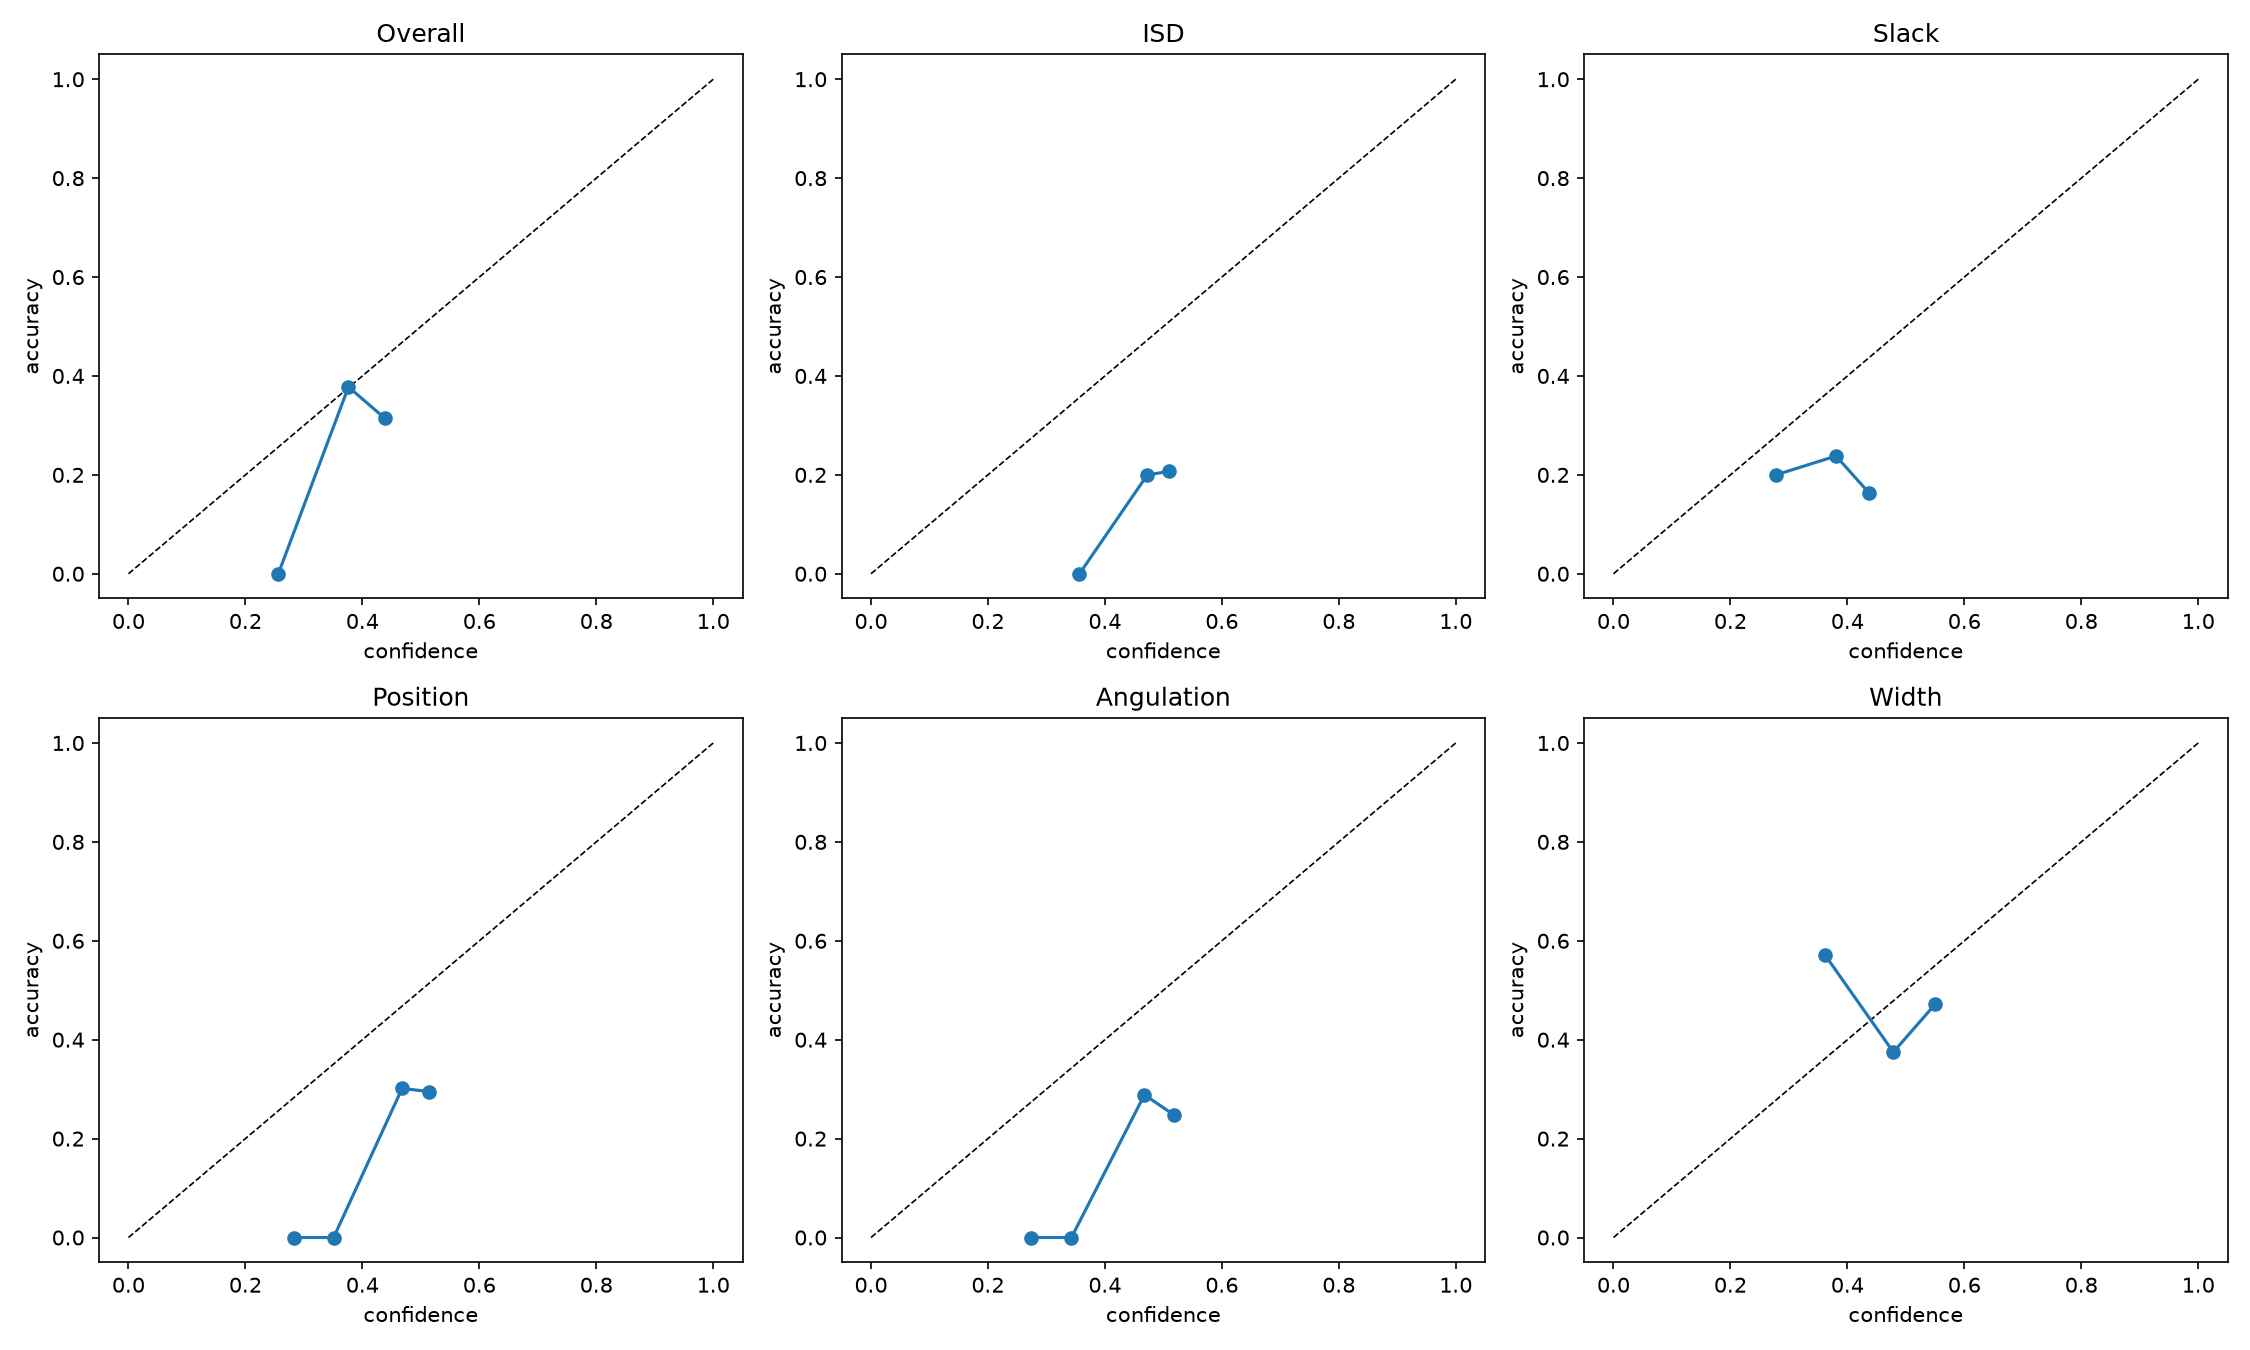

In [5]:
display(Image(filename=str(ARTIFACTS / "calibration-grid.png")))


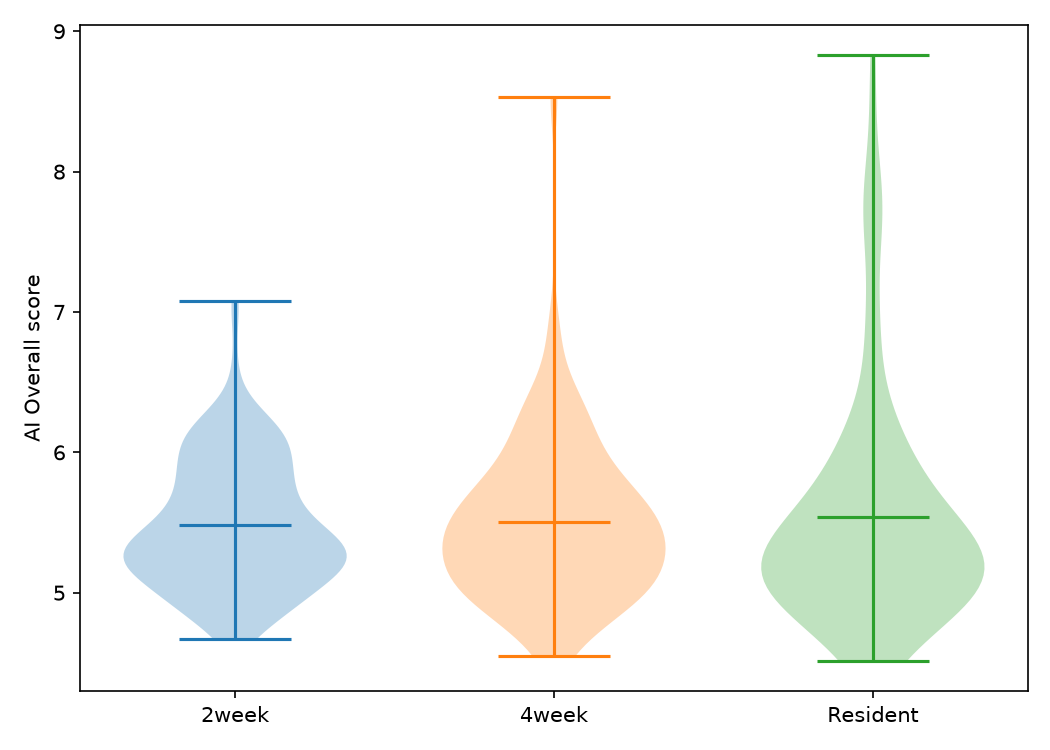

In [6]:
display(Image(filename=str(ARTIFACTS / "trainee-levels.png")))

In [7]:
print((ARTIFACTS / "agreement.md").read_text())

## AI-vs-expert agreement (per trainee level)

| level | output | icc | kappa |
|---|---|---|---|
| 2week | Overall | 0.377 | 0.375 |
| 2week | ISD | 0.000 | 0.000 |
| 2week | Slack | 0.000 | 0.000 |
| 2week | Position | 0.000 | 0.000 |
| 2week | Angulation | 0.000 | 0.000 |
| 2week | Width | -0.000 | 0.000 |
| 4week | Overall | 0.193 | 0.192 |
| 4week | ISD | 0.000 | 0.000 |
| 4week | Slack | 0.000 | 0.000 |
| 4week | Position | 0.000 | 0.000 |
| 4week | Angulation | 0.000 | 0.000 |
| 4week | Width | -0.000 | 0.000 |
| Resident | Overall | -0.100 | -0.099 |
| Resident | ISD | -0.000 | 0.000 |
| Resident | Slack | 0.000 | 0.000 |
| Resident | Position | 0.000 | 0.000 |
| Resident | Angulation | 0.000 | 0.000 |
| Resident | Width | 0.000 | 0.000 |



## Paper status

- `val-metrics.md` holds the official-split final numbers (MAE, exact, ±1,
  Spearman, ECE per output).
- `agreement.md` fills in automatically when real expert labels are supplied
  via `--expert-labels`; it currently reports the graceful not-yet-available
  path.
- All artifacts regenerate from `python -m suture_scoring artifacts
  --scores-dir outputs --val-annotations <val.xlsx> --output-dir artifacts
  [--expert-labels <labels.xlsx>]`.